# Импорт модулей

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns

In [12]:
%matplotlib inline
sns.set_style("whitegrid")

In [13]:
df = pd.read_csv('travel.csv', 
                 parse_dates=['date_time', 'srch_ci', 'srch_co'])

In [14]:
df.head()

,Unnamed: 0,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,24636210,2014-11-03 16:02:28,24,2,77,871,36643,456.1151,792280,0,...,0,1,8286,1,0,1,0,63,1258,68
1,19837144,2013-03-13 19:25:01,11,3,205,135,38749,232.4737,961995,0,...,0,1,1842,3,0,1,2,198,786,37
2,13066459,2014-10-13 13:20:25,2,3,66,314,48562,4468.2720,495669,0,...,0,1,8746,1,0,1,6,105,29,22
3,4691082,2013-11-05 10:40:34,11,3,205,411,52752,171.6021,106611,0,...,0,1,6210,3,1,1,2,198,1234,42
4,4878884,2014-06-10 13:34:56,2,3,66,174,50644,NaN,596177,0,...,1,1,12812,5,0,1,2,50,368,83


# Описание набора данных

date_time - Дата и время, когда юзер сделал поиск

site_name - сайт, через который проходил поиск

posa_continent - континет, в которой был поиск

user_location_country - Страна заказа

user-location-city - Город заказа

orig-destination-distance - Приблизительное расстояние пользователя до отеля

user_id - Айди пользователя

is_mobile - Сделан ли был заказ с мобильного устройства

is_package - Является ли заказ частью пакетного тура

chanell - Канал привлечения

srch-ci - Дата заезда

srch-co - Дата выезда

srch-adults-cnt - Количество взрослых в поиске

srch-childer-cnt - Количество детей в поиске

srch-room-cnt - Количество комнат

srch_destination_id - Айди пункта назначения

srch_destination_type_id - Тип Пункта назначения

is_booking - Пользователь заказал или просто просмотрел

cnt - Количество событий в одном поиске

hotel_continent - Континент, где находиться отель

hotel_country - Страна, где находиться отель

hotel_market - Рынок внутри страны

hotel_cluster - Кластер отеля


# Разведочный анализ

In [15]:
df.shape

(100000, 25)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Unnamed: 0                 100000 non-null  int64         
 1   date_time                  100000 non-null  datetime64[ns]
 2   site_name                  100000 non-null  int64         
 3   posa_continent             100000 non-null  int64         
 4   user_location_country      100000 non-null  int64         
 5   user_location_region       100000 non-null  int64         
 6   user_location_city         100000 non-null  int64         
 7   orig_destination_distance  63915 non-null   float64       
 8   user_id                    100000 non-null  int64         
 9   is_mobile                  100000 non-null  int64         
 10  is_package                 100000 non-null  int64         
 11  channel                    100000 non-null  int64    

In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Unnamed: 0,100000.0,18825295.01454,1012.0,9448967.0,18812118.0,28253073.5,37670090.0,10861830.503724
date_time,100000,2014-04-03 07:16:45.412640256,2013-01-07 00:33:47,2013-10-24 19:31:17.249999872,2014-05-30 09:21:38,2014-09-18 07:40:03,2014-12-31 23:47:14,NaN
site_name,100000.0,9.83857,2.0,2.0,2.0,15.0,53.0,11.996426
posa_continent,100000.0,2.67815,0.0,3.0,3.0,3.0,4.0,0.749018
user_location_country,100000.0,85.99507,0.0,66.0,66.0,70.0,239.0,59.292002
user_location_region,100000.0,308.63699,0.0,174.0,314.0,385.0,1025.0,208.706581
user_location_city,100000.0,27676.39124,0.0,12949.0,27655.0,42328.0,56507.0,16768.647409
orig_destination_distance,63915.0,1960.661721,0.0056,312.7921,1131.8353,2542.35935,11965.3761,2228.153377
user_id,100000.0,605438.33213,14.0,298796.25,602882.5,915722.25,1198783.0,351615.377136
is_mobile,100000.0,0.13377,0.0,0.0,0.0,0.0,1.0,0.340407


В целом можно понять, что обычно люди просто просматривают, но не покупают. В прездках редко берут детейи обычно ездят двое взрослых

# Идентификация кореляций между переменными

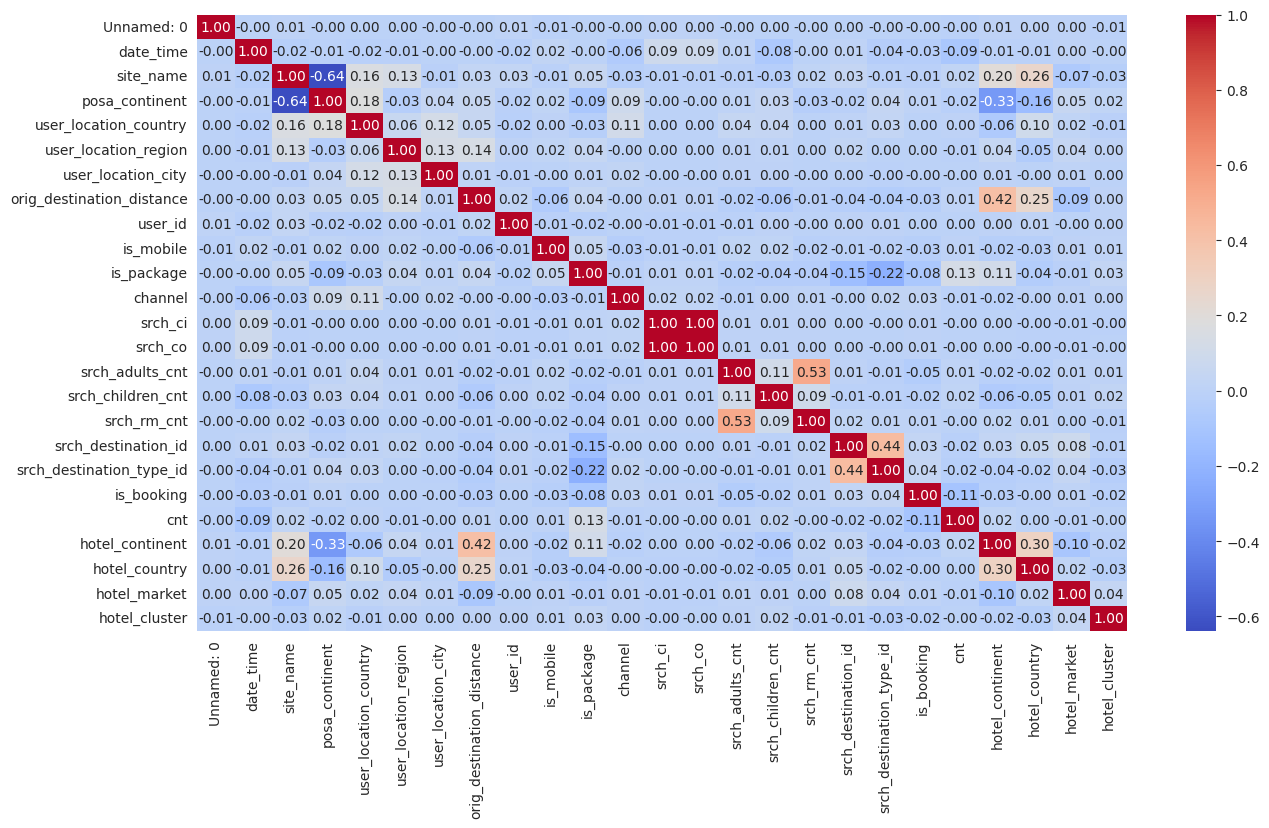

In [20]:
plt.figure(figsize=(15, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.show()

Видна зависимость сайта, в котором проводился поиск и клиентом, также поиск по континенту и отель по континенту. Зависимость континент отеля и приблизительное расстояние клиента до отеля.
Количество комнат и количество взрослых. 

# Целевые признаки

По-моему мнению целевыми признаками можно назвать: 

is_booking - было ли бронирование или это просто просмотр

hotel_cluster - Кластер отеля